## 05 — Model Comparison

Final comparison of all three models trained in this project: Logistic Regression, XGBoost, and LightGBM.

Loads saved test probabilities from notebooks 03 and 04 — no re-training needed. Primary metric: **PR-AUC**.

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    classification_report, precision_recall_curve,
    PrecisionRecallDisplay, RocCurveDisplay, ConfusionMatrixDisplay
)

### Load Predictions

In [2]:
data_dir = Path("../Data/Processed")

lr   = pd.read_csv(data_dir / "predictions_lr.csv")
tree = pd.read_csv(data_dir / "predictions_tree.csv")

y_test    = lr["y_test"]
lr_proba  = lr["lr_proba"]
xgb_proba = tree["xgb_proba"]
lgb_proba = tree["lgb_proba"]

print(f"Test set: {len(y_test):,} rows | fraud rate: {y_test.mean()*100:.2f}%")

Test set: 333,915 rows | fraud rate: 1.71%


### Metrics Summary

In [3]:
models = {
    "Logistic Regression": lr_proba,
    "XGBoost":             xgb_proba,
    "LightGBM":            lgb_proba,
}

rows = []
for name, proba in models.items():
    pr_auc  = average_precision_score(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    rows.append({"Model": name, "PR-AUC": pr_auc, "ROC-AUC": roc_auc})

results = pd.DataFrame(rows).set_index("Model")
baseline = results.loc["Logistic Regression", "PR-AUC"]
results["vs LR"] = results["PR-AUC"] - baseline

print(results[["PR-AUC", "vs LR", "ROC-AUC"]].to_string(float_format="{:.4f}".format))

                     PR-AUC  vs LR  ROC-AUC
Model                                      
Logistic Regression  0.7064 0.0000   0.9741
XGBoost              0.8257 0.1192   0.9897
LightGBM             0.8274 0.1209   0.9895


### Precision-Recall & ROC Curves

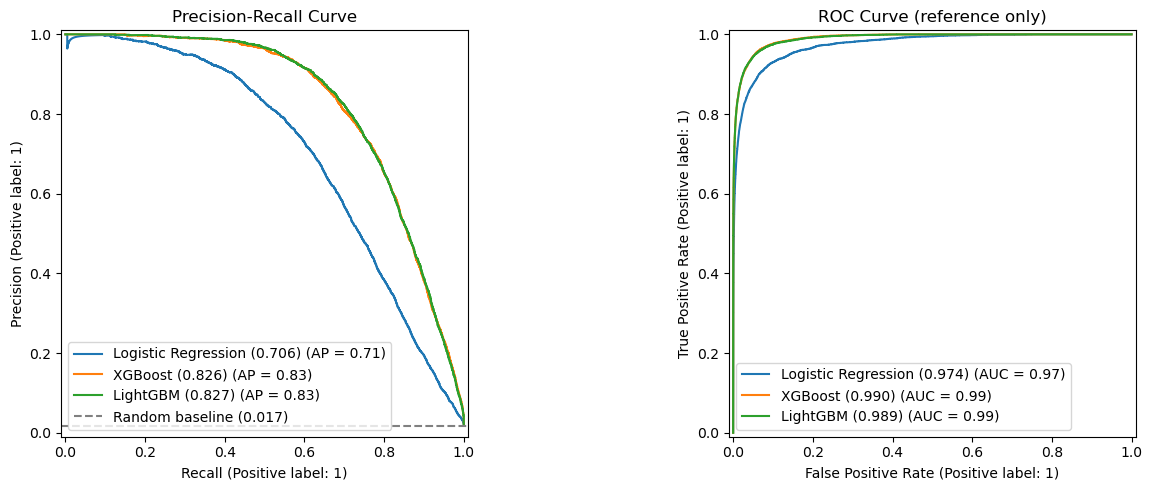

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba in models.items():
    pr_auc  = average_precision_score(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    PrecisionRecallDisplay.from_predictions(
        y_test, proba, ax=axes[0], name=f"{name} ({pr_auc:.3f})")
    RocCurveDisplay.from_predictions(
        y_test, proba, ax=axes[1], name=f"{name} ({roc_auc:.3f})")

axes[0].axhline(y_test.mean(), color="gray", linestyle="--",
                label=f"Random baseline ({y_test.mean():.3f})")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend()

axes[1].set_title("ROC Curve (reference only)")
axes[1].legend()

plt.tight_layout()

### Threshold Tuning & Optimal Classification Reports

In [5]:
def optimal_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
    best_idx = f1_scores.argmax()
    return thresholds[best_idx], f1_scores[best_idx]

for name, proba in models.items():
    thresh, f1 = optimal_threshold(y_test, proba)
    y_pred = (proba >= thresh).astype(int)
    print(f"{name} — optimal threshold: {thresh:.3f} | F1: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))

Logistic Regression — optimal threshold: 0.970 | F1: 0.6593
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99    328190
       Fraud       0.70      0.62      0.66      5725

    accuracy                           0.99    333915
   macro avg       0.85      0.81      0.83    333915
weighted avg       0.99      0.99      0.99    333915

XGBoost — optimal threshold: 0.948 | F1: 0.7521
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    328190
       Fraud       0.78      0.73      0.75      5725

    accuracy                           0.99    333915
   macro avg       0.89      0.86      0.87    333915
weighted avg       0.99      0.99      0.99    333915

LightGBM — optimal threshold: 0.962 | F1: 0.7566
              precision    recall  f1-score   support

       Legit       0.99      1.00      1.00    328190
       Fraud       0.83      0.70      0.76      5725

    accuracy             

### Confusion Matrices at Optimal Threshold

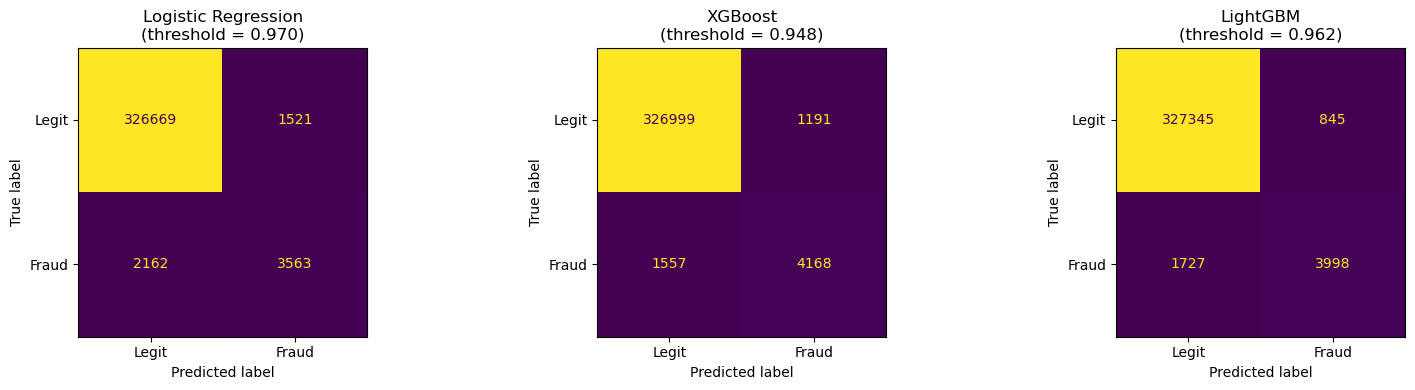

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, proba) in zip(axes, models.items()):
    thresh, _ = optimal_threshold(y_test, proba)
    y_pred = (proba >= thresh).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Legit", "Fraud"],
        ax=ax, colorbar=False)
    ax.set_title(f"{name}\n(threshold = {thresh:.3f})")

plt.tight_layout()

### Conclusion

In [7]:
best_model = results["PR-AUC"].idxmax()
best_pr    = results.loc[best_model, "PR-AUC"]
improvement = results.loc[best_model, "vs LR"]

print(f"Best model:  {best_model}")
print(f"PR-AUC:      {best_pr:.4f}  (+{improvement:.4f} vs Logistic Regression baseline)")

Best model:  LightGBM
PR-AUC:      0.8274  (+0.1209 vs Logistic Regression baseline)
